In [2]:
#Thêm thư viện
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
#Nạp dữ liệu
df = pd.read_csv('/content/Ecommerce Customers')

In [4]:
#Hiển thị 5 dòng đầu tiên của DataFrame
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [5]:
#Hiển thị thông tin tổng quan
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


In [6]:
#Thống kê nhanh
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [7]:
# Xóa Ba cột Email, Address, Avatar
df = df.drop(['Email', 'Address', 'Avatar'], axis=1)


In [8]:
df.head()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,34.497268,12.655651,39.577668,4.082621,587.951054
1,31.926272,11.109461,37.268959,2.664034,392.204933
2,33.000915,11.330278,37.110597,4.104543,487.547505
3,34.305557,13.717514,36.721283,3.120179,581.852344
4,33.330673,12.795189,37.536653,4.446308,599.406092


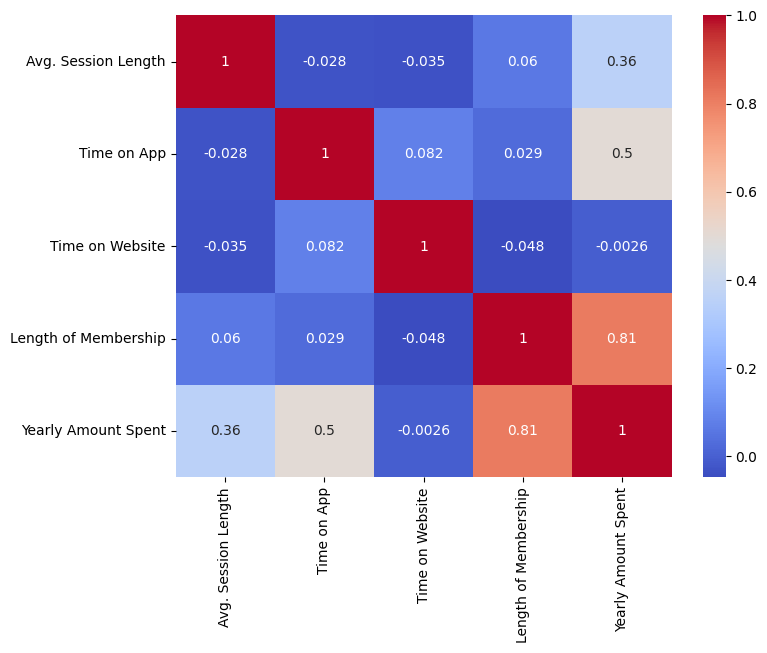

In [9]:
# Kiểm tra tương quan
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
# Select only numerical columns before calculating the correlation
numerical_df = df.select_dtypes(include=np.number)
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm')
plt.show()

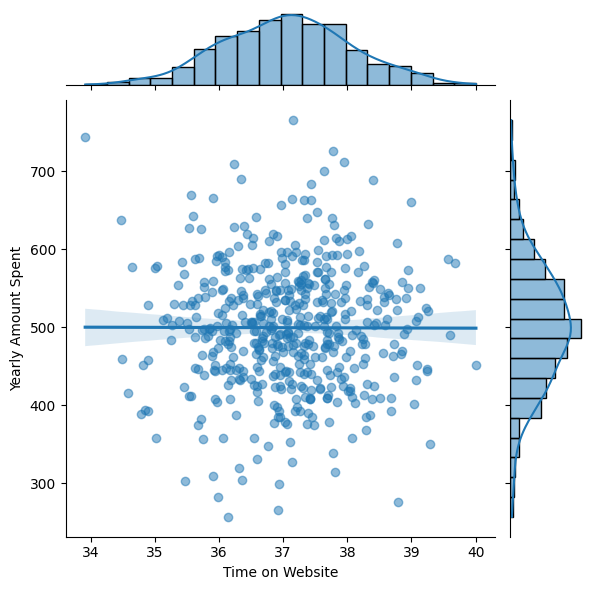

In [10]:
#EDA
# mối quan hệ giữa thời gian khách hàng ở trên website và số tiền họ chi tiêu mỗi năm
sns.jointplot(
    x='Time on Website',
    y='Yearly Amount Spent',
    data=df,
    kind='reg',   # vẽ thêm đường hồi quy
    scatter_kws={'alpha': 0.5}
)

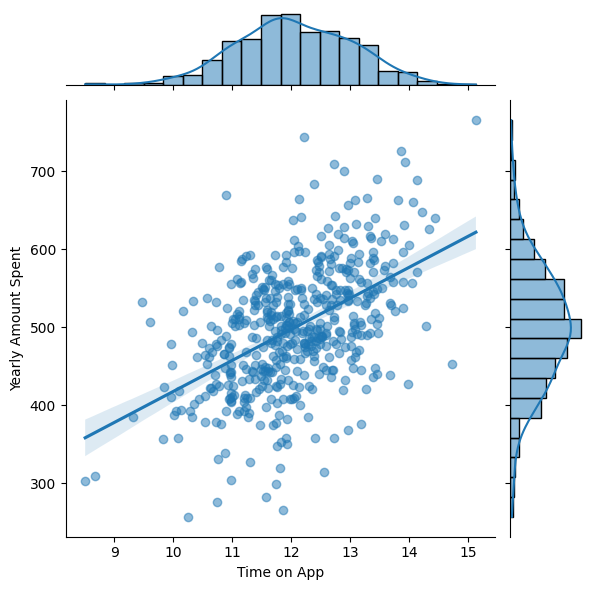

In [11]:
#Mối quan hệ giữa thời gian khách hàng ở trên app và số tiền họ chi tiêu mỗi năm
sns.jointplot(
    x='Time on App',
    y='Yearly Amount Spent',
    data=df,
    kind='reg',               # Vẽ thêm đường hồi quy
    scatter_kws={'alpha': 0.5} # Độ trong suốt cho điểm
)

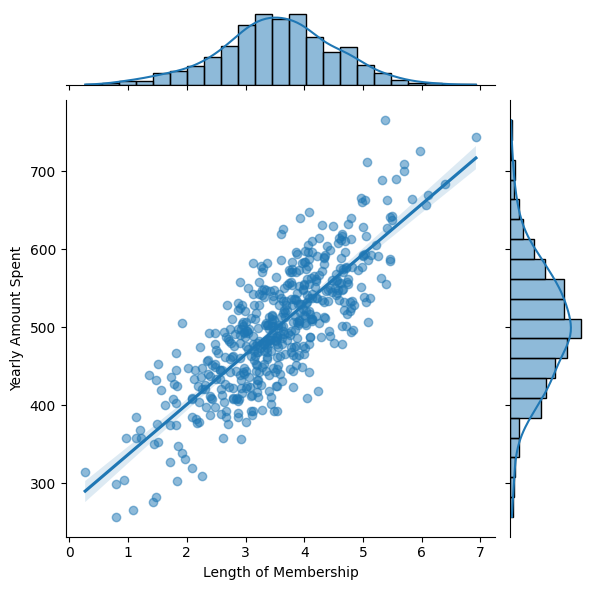

In [38]:
#Mối quan hệ giữa thời gian khách hàng ở trên app và số tiền họ chi tiêu mỗi năm
sns.jointplot(
    x='Length of Membership',
    y='Yearly Amount Spent',
    data=df,
    kind='reg',               # Vẽ thêm đường hồi quy
    scatter_kws={'alpha': 0.5} # Độ trong suốt cho điểm
)

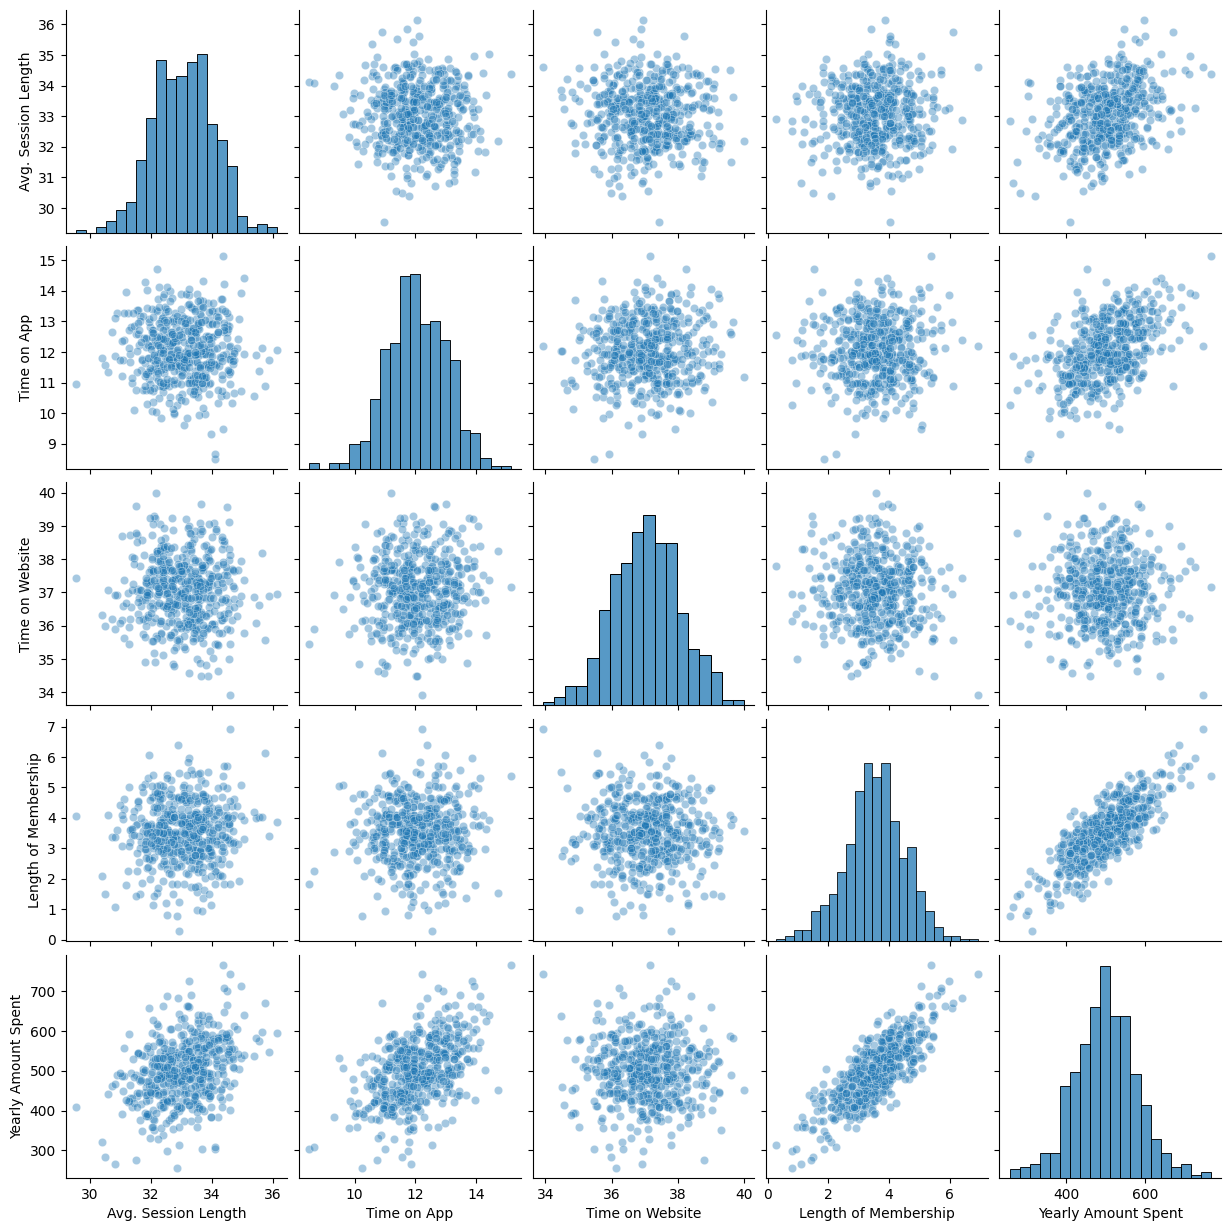

In [12]:
#Ma trận biểu đồ phân tán (scatter plot matrix) cho tất cả các cặp cột
sns.pairplot(df, kind = 'scatter', plot_kws = {'alpha' : 0.4})

# Tách biến phụ thuộc và biến độc lập

In [15]:
df.columns

Index(['Avg. Session Length', 'Time on App', 'Time on Website',
       'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

In [16]:
X = df[['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']]
y = df['Yearly Amount Spent']

In [17]:
X

,Avg. Session Length,Time on App,Time on Website,Length of Membership
0,34.497268,12.655651,39.577668,4.082621
1,31.926272,11.109461,37.268959,2.664034
2,33.000915,11.330278,37.110597,4.104543
3,34.305557,13.717514,36.721283,3.120179
4,33.330673,12.795189,37.536653,4.446308
...,...,...,...,...
495,33.237660,13.566160,36.417985,3.746573
496,34.702529,11.695736,37.190268,3.576526
497,32.646777,11.499409,38.332576,4.958264
498,33.322501,12.391423,36.840086,2.336485


In [18]:
y

,Yearly Amount Spent
0,587.951054
1,392.204933
2,487.547505
3,581.852344
4,599.406092
...,...
495,573.847438
496,529.049004
497,551.620145
498,456.469510


# Chia tập dữ liệu thành tập huấn luyện và kiểm thử

In [19]:
#Thêm thư viện train_test_split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [20]:
X_train

,Avg. Session Length,Time on App,Time on Website,Length of Membership
5,33.871038,12.026925,34.476878,5.493507
116,33.925795,12.011022,36.701052,2.753424
45,34.555768,12.170525,39.131097,3.663105
16,32.125387,11.733862,34.894093,3.136133
462,33.503810,11.233415,37.211153,2.320550
...,...,...,...,...
106,32.291756,12.190474,36.152462,3.781823
270,34.006489,12.956277,38.655095,3.275734
348,31.812483,10.886921,34.897828,3.128639
435,32.259973,14.132893,37.023479,3.762070


In [21]:
X_test

,Avg. Session Length,Time on App,Time on Website,Length of Membership
361,32.077590,10.347877,39.045156,3.434560
73,32.808698,12.817113,37.031539,3.851579
374,31.447446,10.101632,38.043453,4.238296
155,32.449522,13.457725,37.238806,2.941411
104,31.389585,10.994224,38.074452,3.428860
...,...,...,...,...
266,34.555283,11.777772,37.979827,3.784273
23,32.903251,11.657576,36.772604,3.919302
222,34.334865,11.109456,38.585855,3.892891
261,32.550527,13.041245,36.655208,3.456234


In [22]:
y_train

,Yearly Amount Spent
5,637.102448
116,479.231093
45,549.860590
16,457.847696
462,397.420584
...,...
106,494.551861
270,540.995739
348,392.810345
435,571.216005


In [23]:
y_test

,Yearly Amount Spent
361,401.033135
73,534.777188
374,418.602742
155,503.978379
104,410.069611
...,...
266,554.003093
23,519.340989
222,502.409785
261,514.009818


# Huấn luyện bằng mô hình hồi quy tuyến tính

In [24]:
#training the model
from sklearn.linear_model import LinearRegression

In [25]:
#  Khởi tạo mô hình
regressor = LinearRegression()

In [26]:
#  Huấn luyện trên tập train
regressor = LinearRegression()

LinearRegression()

In [27]:
#Xem hệ số của mô hình
regressor.coef_

array([25.72425621, 38.59713548,  0.45914788, 61.67473243])

In [28]:
#Tạo DataFrame để xem hệ số
cdf = pd.DataFrame(regressor.coef_, X.columns, columns = ['Coef'])
print(cdf)

                           Coef
Avg. Session Length   25.724256
Time on App           38.597135
Time on Website        0.459148
Length of Membership  61.674732


# Dự đoán trên tập kiểm thử

In [29]:
X_test

,Avg. Session Length,Time on App,Time on Website,Length of Membership
361,32.077590,10.347877,39.045156,3.434560
73,32.808698,12.817113,37.031539,3.851579
374,31.447446,10.101632,38.043453,4.238296
155,32.449522,13.457725,37.238806,2.941411
104,31.389585,10.994224,38.074452,3.428860
...,...,...,...,...
266,34.555283,11.777772,37.979827,3.784273
23,32.903251,11.657576,36.772604,3.919302
222,34.334865,11.109456,38.585855,3.892891
261,32.550527,13.041245,36.655208,3.456234


In [30]:
y_predict = regressor.predict(X_test)
y_predict

array([403.66993069, 542.57756289, 427.06591658, 502.02460425,
       410.12143559, 569.93442508, 531.93431341, 506.29650969,
       408.71870658, 473.97737105, 441.46912726, 425.33703059,
       425.1297229 , 527.61676714, 431.45684016, 424.0769184 ,
       575.76543296, 484.89856554, 458.35936863, 481.96502182,
       502.32441491, 513.63783554, 507.58877002, 646.57464283,
       450.24372141, 496.27043415, 556.40457807, 554.95630839,
       399.64237199, 325.84623136, 532.89783259, 478.12238702,
       501.05701845, 305.97335848, 505.77244448, 483.79591969,
       518.8331528 , 438.18241857, 456.71094234, 471.04609461,
       494.44008972, 445.31155755, 508.78802753, 501.04594193,
       488.83499673, 535.38079541, 595.20129802, 514.04714872,
       280.76758312, 433.10112367, 421.70823427, 481.23640152,
       584.71372272, 608.7748096 , 563.98513427, 494.72804869,
       394.52133407, 456.4197529 , 573.08767515, 499.6984241 ,
       512.83277025, 392.12434043, 480.05057697, 481.54

# Vẽ biểu đồ đường thẳng hồi quy

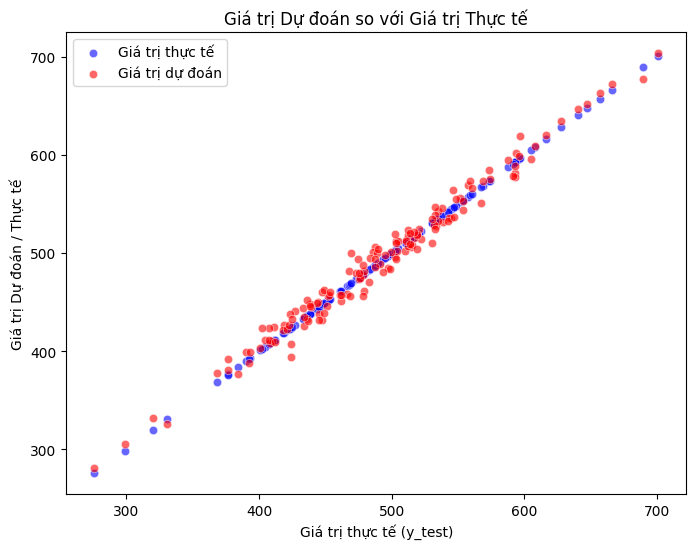

In [31]:
# Create the scatter plot
plt.figure(figsize=(8, 6))

# Actual values
sns.scatterplot(x=y_test, y=y_test, color="blue", label="Giá trị thực tế", alpha=0.6)

# Predicted values
sns.scatterplot(x=y_test, y=y_predict, color="red", label="Giá trị dự đoán", alpha=0.6)

# Labels and title
plt.xlabel("Giá trị thực tế (y_test)")
plt.ylabel("Giá trị Dự đoán / Thực tế")
plt.title("Giá trị Dự đoán so với Giá trị Thực tế")
plt.legend()
plt.show()

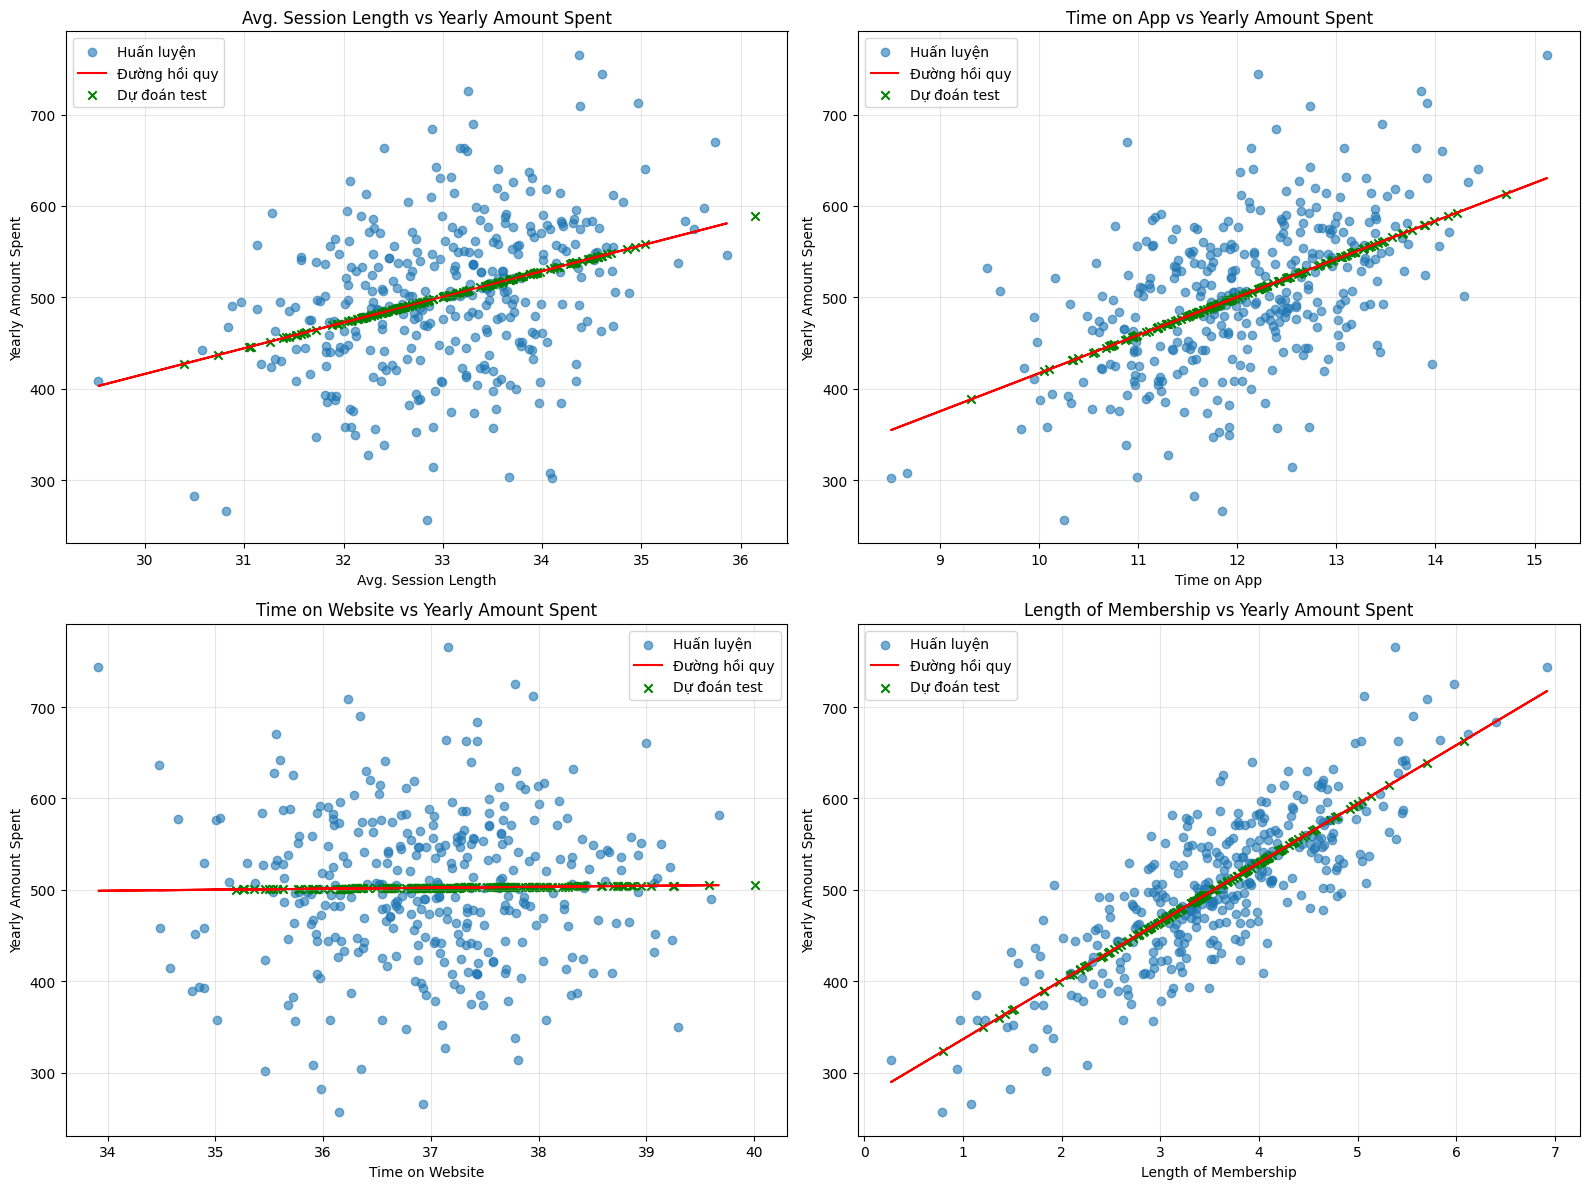

In [32]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

features = X_train.columns
n_features = len(features)

plt.figure(figsize=(16, 12))

for i, feature in enumerate(features):
    # Chuẩn bị dữ liệu cho feature hiện tại
    X_train_single = X_train[[feature]].values  # giữ dạng 2D
    X_test_single = X_test[[feature]].values

    # Train Linear Regression chỉ với feature này
    reg_single = LinearRegression()
    reg_single.fit(X_train_single, y_train)
    y_pred_test = reg_single.predict(X_test_single)

    # Tạo subplot
    plt.subplot(2, 2, i+1)
    plt.scatter(X_train_single, y_train, alpha=0.6, label='Huấn luyện')
    plt.plot(X_train_single, reg_single.predict(X_train_single), color='red', label='Đường hồi quy')
    plt.scatter(X_test_single, y_pred_test, color='green', marker='x', label='Dự đoán test')

    plt.xlabel(feature)
    plt.ylabel('Yearly Amount Spent')
    plt.title(f'{feature} vs Yearly Amount Spent')
    plt.legend()
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()



# Đánh giá mô hình

In [33]:
#Thêm thư viện đánh giá dựa trên độ đo (3 tham số dự đoán)
from sklearn.metrics  import mean_squared_error, mean_absolute_error
import math

In [34]:
print("Mean Squared Error: ", mean_squared_error(y_test, y_predict))
print("Mean Absolute Error: ", mean_absolute_error(y_test, y_predict))
print("RMSE: ", math.sqrt(mean_squared_error(y_test, y_predict)))
r2 = r2_score(y_test, y_predict)
print("R² Score:", r2)

Mean Squared Error:  103.91554136503333
Mean Absolute Error:  8.426091641432116
RMSE:  10.193897260863155
R² Score: 0.9808757641125855


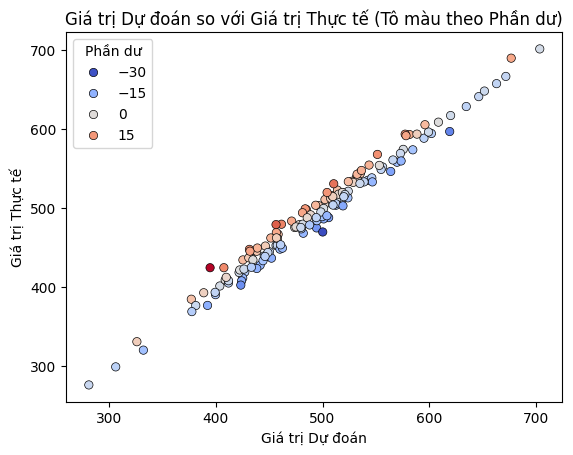

In [35]:
# Calculate residuals (errors)
residuals = y_test - y_predict

# Scatter plot with color based on residuals
sns.scatterplot(x=y_predict, y=y_test, hue=residuals, palette="coolwarm", edgecolor="black")

# Labels and title
plt.xlabel("Giá trị Dự đoán")
plt.ylabel("Giá trị Thực tế")
plt.title("Giá trị Dự đoán so với Giá trị Thực tế (Tô màu theo Phần dư)")
plt.legend(title="Phần dư")
plt.show()

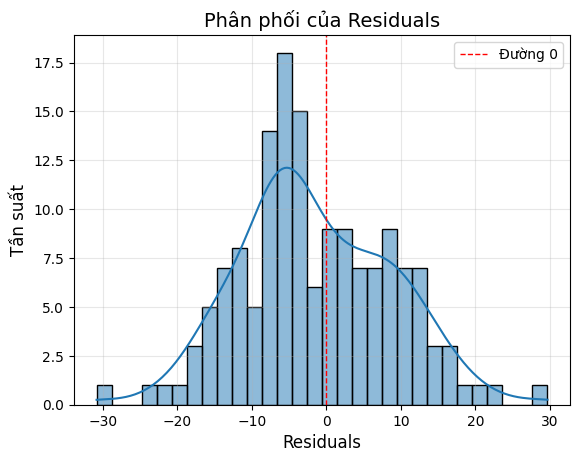

In [36]:
sns.histplot(residuals, bins=30, kde=True, edgecolor="black")
# Vẽ đường dọc tại giá trị 0 (trung tâm phân phối chuẩn)
plt.axvline(x=0, color="red", linestyle="--", linewidth=1, label="Đường 0")

# Tùy chỉnh
plt.title("Phân phối của Residuals", fontsize=14)
plt.xlabel("Residuals", fontsize=12)
plt.ylabel("Tần suất", fontsize=12)
plt.legend()
plt.grid(alpha=0.3)

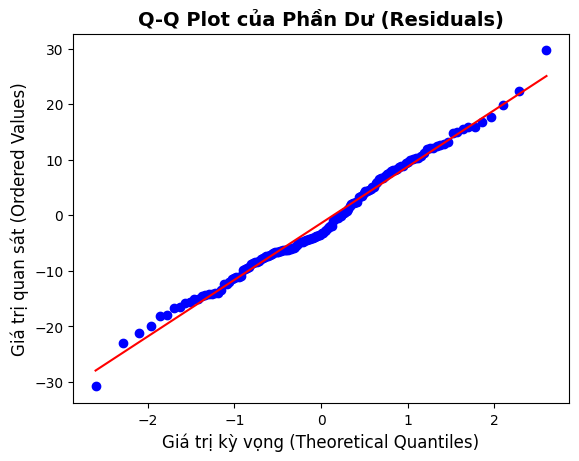

In [37]:
#kiểm tra giả định phân phối chuẩn của phần dư thông qua Q-Q plot
import pylab
import scipy.stats as stats

stats.probplot(residuals, dist = 'norm', plot = pylab)
# Tùy chỉnh tiêu đề và trục
plt.title("Q-Q Plot của Phần Dư (Residuals)", fontsize=14, fontweight="bold")
plt.xlabel("Giá trị kỳ vọng (Theoretical Quantiles)", fontsize=12)
plt.ylabel("Giá trị quan sát (Ordered Values)", fontsize=12)
pylab.show()